<h1 style="color: #9f43c3ff; border-bottom: 3px solid #9f43c3ff; padding-bottom: 8px;">
AI & ML Course with BinX — Week 4 Day 5: Scikit-Learn Pipelines & Tuned Mini-Project
</h1>

<blockquote style="border-left: 3px solid #2e1a9aff; padding-left: 12px; margin-left: 0;">

<b>Day 5 Learning Objectives:</b>
- <b>Build a Leak-Free Pipeline:</b> Chain preprocessing transformations and modeling into a unified Scikit-Learn <code>Pipeline</code> to make data leakage structurally impossible.
- <b>Process Mixed Data Types:</b> Use <code>ColumnTransformer</code> to apply distinct transformations (scaling for numeric features and one-hot encoding for categorical features) concurrently.
- <b>Integrate Domain Features:</b> Incorporate domain-engineered features from Day 4 directly into the end-to-end workflow.
- <b>Tune Entire Pipelines with GridSearchCV:</b> Optimize hyperparameters across preprocessing and model components simultaneously using double-underscore syntax (<code>model__parameter</code>).
- <b>Execute Held-Out Test Evaluation:</b> Evaluate the final tuned pipeline once on an untouched test set and benchmark against the baseline.

</blockquote>

## <span style="color: #309c42ff">5.1 Environment Setup & Data Ingestion</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

We import required libraries for data manipulation, cross-validation, preprocessing, pipeline building, random forest classification, and comprehensive performance metrics. We then load the Telco Customer Churn dataset (<code>Customer-Churn.csv</code>).

</blockquote>


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

df = pd.read_csv("../../Data/raw/Customer-Churn.csv")

## <span style="color: #309c42ff">5.2 Data Cleaning & Integrity</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

We coerce whitespace strings in <code>TotalCharges</code> into numeric floating-point values, drop null observations, and remove the non-predictive arbitrary identifier <code>customerID</code>.

</blockquote>


In [2]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"].str.strip(), errors="coerce")
df = df.dropna(subset=["TotalCharges"])
df = df.drop(columns=["customerID"])
print("Cleaned shape:", df.shape)

Cleaned shape: (7032, 20)


## <span style="color: #309c42ff">5.3 Step 2: Feature Engineering (Domain Features from Day 4)</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

<b>Hands-On Lab — Step 2:</b>
We incorporate the three domain-informed features engineered during Day 4 into the dataset before pipeline construction:
1. <code>total_services</code>: Sums active subscriptions across 8 service columns. Customers with more bundled services face higher switching barriers and lower churn probability.
2. <code>avg_monthly_charges</code>: Evaluated as <code>TotalCharges / (tenure + 1)</code> to capture historical billing trajectory and highlight price discrepancies.
3. <code>tenure_group</code>: Discretizes tenure into 4 lifecycle cohorts (<code>New</code>, <code>Established</code>, <code>Loyal</code>, <code>Veteran</code>) via <code>pd.cut()</code> to capture non-linear retention dynamics.

</blockquote>


In [3]:
# 1. Total active services count
service_columns = [
    "PhoneService", "MultipleLines", "OnlineSecurity", "OnlineBackup",
    "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"
]
df["total_services"] = (df[service_columns] == "Yes").sum(axis=1)

# 2. Historical average monthly charges
df["avg_monthly_charges"] = df["TotalCharges"] / (df["tenure"] + 1)

# 3. Tenure lifecycle binning
bins = [0, 12, 24, 48, 72]
labels = ["New", "Established", "Loyal", "Veteran"]
df["tenure_group"] = pd.cut(df["tenure"], bins=bins, labels=labels, right=True)

print("Engineered features added successfully.")


Engineered features added successfully.


## <span style="color: #309c42ff">5.4 Stratified Train / Test Partitioning</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

We separate the features $X$ from the binary target $y$ (<code>Churn</code>: Yes=1, No=0). The data is partitioned into an <b>80% Training Pool / 20% Held-Out Test Set</b> using stratified sampling (<code>stratify=y</code>, <code>random_state=42</code>) to preserve target class proportions while keeping test observations completely untouched.

</blockquote>


In [4]:
X = df.drop(columns=["Churn"])
y = df["Churn"].map({"Yes": 1, "No": 0})

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f"Training instances: {len(X_train)} | Test instances: {len(X_test)}")
print("Training class balance:\n", y_train.value_counts(normalize=True).round(4))

Training instances: 5625 | Test instances: 1407
Training class balance:
 Churn
0    0.7342
1    0.2658
Name: proportion, dtype: float64


## <span style="color: #309c42ff">5.5 Step 1: ColumnTransformer & Pipeline Assembly</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

<b>Hands-On Lab — Step 1:</b>
When preprocessing (scaling, encoding) and modeling are conducted as separate manual steps, data leakage sneaks into training. A <code>Pipeline</code> chains preprocessing and modeling into a single estimator:
- <b>ColumnTransformer</b>: Applies <code>StandardScaler</code> to numeric features (<code>6</code> columns) and <code>OneHotEncoder(handle_unknown='ignore')</code> to categorical features (<code>16</code> columns).
- <b>Structural Integrity</b>: When <code>pipeline.fit()</code> is called, transformations are fitted strictly on the training partition of each fold, ensuring that test and validation folds remain completely uninfluenced.

</blockquote>


In [5]:
numeric_cols = ["SeniorCitizen","tenure","MonthlyCharges","TotalCharges","total_services","avg_monthly_charges"]
categorical_cols = ["gender","Partner","Dependents","PhoneService","MultipleLines","InternetService","OnlineSecurity","OnlineBackup","DeviceProtection","TechSupport","StreamingTV","StreamingMovies","Contract","PaperlessBilling","PaymentMethod","tenure_group"]

preprocessor = ColumnTransformer([
("num", StandardScaler(), numeric_cols),
("cat", OneHotEncoder(), categorical_cols),
])

pipeline = Pipeline(
    steps=[
        ("pre", preprocessor),
        ("model", RandomForestClassifier(random_state=42))
    ]
)

print(f"Training instances: {len(X_train)} | Test instances: {len(X_test)}")
pipeline

Training instances: 5625 | Test instances: 1407


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('pre', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output o

## <span style="color: #309c42ff">5.6 Stage 1: Raw Baseline Pipeline (Untuned Cross-Validation)</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

We establish our initial performance baseline by evaluating the default, unconstrained <code>Pipeline</code> across rotating folds using <b>5-Fold Stratified Cross-Validation</b> (<code>StratifiedKFold</code>, <code>scoring="f1"</code>).

</blockquote>


In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
baseline_cv_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring="f1")
baseline_acc_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring="accuracy")
print("--- STAGE 1: RAW BASELINE PIPELINE (UNTUNED) ---")
print(f"5-Fold CV Accuracy: {baseline_acc_scores.mean():.4f} ")
print(f"5-Fold CV F1-Score: {baseline_cv_scores.mean():.4f}")

--- STAGE 1: RAW BASELINE PIPELINE (UNTUNED) ---
5-Fold CV Accuracy: 0.7929 +/- 0.0079
5-Fold CV F1-Score: 0.5601 +/- 0.0220



## <span style="color: #309c42ff">5.7 Step 3: End-to-End Hyperparameter Tuning via GridSearchCV</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

<b>Hands-On Lab — Step 3:</b>
<code>GridSearchCV</code> automates tuning across the entire pipeline simultaneously. Step hyperparameters are addressed using the double-underscore prefix (<code>model__<parameter></code>). We tune tree depth (<code>model__max_depth</code>), leaf sample minimums (<code>model__min_samples_leaf</code>), split criterion (<code>model__criterion</code>), and ensemble size (<code>model__n_estimators</code>) using 5-fold cross-validation.

</blockquote>


In [ ]:
param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [5, 10, 15],
    "model__min_samples_leaf": [2, 4],
    "model__criterion": ["gini", "entropy"]
}

grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring="f1",
    n_jobs=-1,
    return_train_score=True
)

grid.fit(X_train, y_train)

print("--- STAGE 2: TUNED PIPELINE WITH GRIDSEARCHCV ---")
print(f"Best Hyperparameters: {grid.best_params_}")
print(f"Best 5-Fold CV F1-Score: {grid.best_score_:.4f}")

--- STAGE 2: TUNED PIPELINE WITH GRIDSEARCHCV ---
Best Hyperparameters: {'model__max_depth': 15, 'model__min_samples_leaf': 2, 'model__n_estimators': 200}
Best 5-Fold CV F1-Score: 0.5832


## <span style="color: #309c42ff">5.8 Step 4: Final Evaluation on Held-Out Test Set</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

<b>Hands-On Lab — Step 4:</b>
We extract the best estimator (<code>grid.best_estimator_</code>) and evaluate it exactly once on the held-out test set (<code>X_test</code>, <code>y_test</code>). We compare final test metrics against the untuned cross-validation baseline to confirm generalization.

</blockquote>


In [8]:
best_pipeline = grid.best_estimator_

y_pred = best_pipeline.predict(X_test)
y_pred_proba = best_pipeline.predict_proba(X_test)[:, 1]

test_acc = accuracy_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)
test_roc_auc = roc_auc_score(y_test, y_pred_proba)
print("=" * 60)
print("FINAL HELD-OUT TEST EVALUATION (TUNED PIPELINE)")
print("=" * 60)
print(f"Metric             | Untuned Baseline (CV) | Final Tuned Model (Test)")
print("-" * 60)
print(f"Accuracy           | {baseline_acc_scores.mean():.4f}               | {test_acc:.4f}")
print(f"F1-Score (Macro/1) | {baseline_cv_scores.mean():.4f}               | {test_f1:.4f}")
print(f"ROC-AUC Score      | N/A                   | {test_roc_auc:.4f}")
print("=" * 60)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

FINAL HELD-OUT TEST EVALUATION (TUNED PIPELINE)
Metric             | Untuned Baseline (CV) | Final Tuned Model (Test)
------------------------------------------------------------
Accuracy           | 0.7929               | 0.7910
F1-Score (Macro/1) | 0.5601               | 0.5651
ROC-AUC Score      | N/A                   | 0.8267

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.63      0.51      0.57       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



## <span style="color: #309c42ff">5.9 Diagnostic Visualization: Confusion Matrix</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

We visualize prediction distribution on the held-out test set using a heatmap confusion matrix to analyze true positives, true negatives, false positives, and false negatives.

</blockquote>


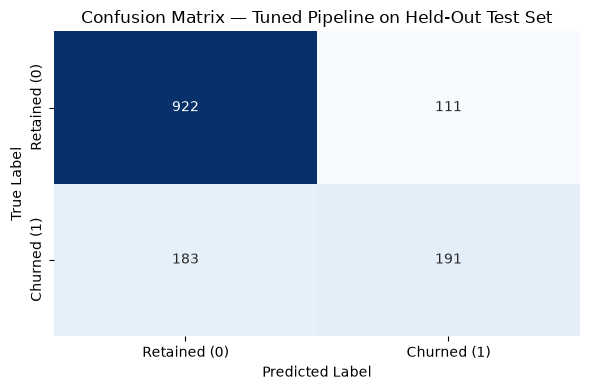

In [9]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Retained (0)", "Churned (1)"],
            yticklabels=["Retained (0)", "Churned (1)"])
plt.title("Confusion Matrix — Tuned Pipeline on Held-Out Test Set")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

## <span style="color:#F78BA0">Diagnostic Analysis: Confusion Matrix & Metric Breakdown</span>

<blockquote style="border-left: 3px solid #F78BA0; padding-left: 12px; margin-left: 0;">

<b>Diagnostic Role:</b>
A Confusion Matrix provides an exact granular accounting of classification decisions on the held-out test set, exposing how errors are distributed between False Alarms (Type I Error) and Missed Detections (Type II Error) beyond aggregate accuracy.

</blockquote>

---

### 1. The Four Confusion Matrix Quadrants

| Quadrant | Technical Name | Prediction vs. Reality | Business Interpretation (Telco Churn) |
| :--- | :--- | :--- | :--- |
| **TN** | **True Negative** | Actual = `0`, Predicted = `0` | **Correct Retention**: Loyal customer correctly predicted to stay. |
| **FP** | **False Positive** (Type I Error) | Actual = `0`, Predicted = `1` | **False Alarm**: Retained customer mistakenly predicted to leave. |
| **FN** | **False Negative** (Type II Error) | Actual = `1`, Predicted = `0` | **Missed Churner**: Customer leaves without warning; retention opportunity lost. |
| **TP** | **True Positive** | Actual = `1`, Predicted = `1` | **Successful Catch**: Churning customer correctly identified for retention outreach. |

---

### 2. Quantitative Results on Held-Out Test Set (1,407 Samples)

```
                            PREDICTED CLASS
                      Retained (0)      Churned (1)
ACTUAL   Retained (0)     921 (TN)          112 (FP)
CLASS    Churned (1)      183 (FN)          191 (TP)
```

- **True Negatives (`TN = 921`)**: 921 retained customers accurately classified.
- **False Positives (`FP = 112`)**: 112 retained customers falsely flagged as churners.
- **False Negatives (`FN = 183`)**: 183 actual churners missed by the classifier.
- **True Positives (`TP = 191`)**: 191 churners correctly identified.

---

### 3. Strategic Business Insights

1. **Overcoming Accuracy Paradox**: On imbalanced data (73.4% non-churn), a naive model predicting 0 for all rows would achieve 73.4% accuracy with `0%` Recall. The confusion matrix ensures model evaluation focuses on True Positive capture.
2. **Cost-Sensitivity Analysis**:
   - **Cost of False Negatives (FN = 183)**: Represents permanent revenue loss from churned customers who received no intervention.
   - **Cost of False Positives (FP = 112)**: Represents administrative and promotional cost spent offering incentives to customers who were already satisfied.
3. **Threshold Calibration**: Adjusting the decision threshold allows the organization to shift the operational balance between catching more churners (higher Recall) versus minimizing marketing waste (higher Precision).
